# Tutorial 2: Dense BioModels Parameter Sweep (`MODEL1907260003`)

Estimated time: 30-50 minutes

## Prerequisites — install BEFORE running this notebook

This tutorial executes a **published BioModels SBML model** (Lever et al. 2014). Beyond the framework + tutorial infrastructure that all tutorials need, T2 specifically requires the **BioModels SBML simulator**:

| Need | Why | Install command |
|---|---|---|
| `bayesian-metamodeling` + `[tutorials]` | Framework runtime + jupyter/matplotlib/numpy. Same as every tutorial. | `pip install -e ".[tutorials]"` |
| **`libroadrunner` + `tellurium`** | **T2 only.** The BioModels worker uses `libroadrunner` to actually simulate the SBML model. **Without these, Step 2 will skip with a preflight banner — Steps 1, 3, 4 still teach the lesson.** | `pip install libroadrunner tellurium` *or* `pip install -e ".[biomodels]"` |
| Network access (first run) | Downloads `MODEL1907260003.xml` (~1.4 MB) from EBI BioModels. After that the SBML is cached. | n/a — or set `MM_BIOMODELS_OFFLINE=1` and pre-populate the cache |

> **Heads up: `libroadrunner` and `tellurium` are PyPI-only — they are NOT on conda-forge.** Even if you're using a conda env, install them with `pip` (pip works inside a conda env). If you have multiple Python environments, make sure to activate the one running this notebook's kernel before installing — the bootstrap cell below prints the kernel's env path so you can check.

**If you don't want to install `libroadrunner` right now**, that's fine: the bootstrap cell below detects this and prints a multi-line preflight banner explaining what to install, in which env, and which steps still teach. You can do T2 in two passes: first read-through (Steps 1, 3, 4) without installing, then come back and install + re-execute when you want the actual SBML run.

(See Tutorial 0 for the full framework-vs-tutorial-vs-T2-only dependency matrix.)

## Learning aims
- Primary package aim: run a real SBML model via the typed adapter workflow using the CLI from inside Jupyter.
- Secondary scientific aim: connect the `k_on` association-rate parameter to dynamic pathway behavior over time.

## Success criteria
- You generate and validate a dense `k_on` sweep spec.
- You attempt a full run and inspect outputs (or the preflight banner explains why Step 2 was skipped).
- You can name what `k_on` means biologically and predict how varying it should reshape the dynamic response.


## Why this tutorial matters

`MODEL1907260003` is a **published BioModels entry** — Lever, Maini, van der Merwe & Dushek, "Phenotypic models of T cell activation," *Nature Reviews Immunology* 2014 (PubMed 25145757). It's a phenotypic model of the kinetic proofreading mechanism governing T-cell receptor / peptide-MHC interactions. We don't need to recreate its biology here; we need to **use it as if it were one of our own models**.

This is the moment you stop running toy programs and start running real published systems with the **same spec contract** you used in T1. The output channel changes (a 1D scalar in T1 becomes a 2D time-series here), the runtime changes (libroadrunner SBML simulation rather than a toy `python` invocation), but the spec-driven workflow is identical. Recognize that, and any BioModels entry becomes available to you with one spec file.


## Step 1: Build a dense sweep spec, then validate and plan

**What is `k_on` biologically?**

`k_on` is the *forward (association) rate constant* for the ligand-receptor binding reaction `L + R → LR`. Units: `1/(M·s)`. Larger `k_on` means **faster complex formation** at a given concentration of `L` and `R`. In TCR signaling, `k_on` (along with `k_off` and lifetime statistics) is what determines whether a peptide-MHC encounter triggers downstream activation or dissociates without effect — exactly the "kinetic proofreading" the Lever 2014 model formalizes.

We're sweeping `k_on` across `[8×10⁻⁵, 1.2×10⁻⁴] 1/(M·s)`, an 11-point grid covering the published parameter ±20%. The biological question we're testing visually with the heatmap below: *does the system's dynamic response shift in a smooth, monotonic way as `k_on` varies, or does it have qualitatively different regimes?*


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import importlib.util
import os
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)

# --- Tutorial 2 setup: build a denser BioModels k_on sweep + seed the offline cache ---
import json
import shutil

import numpy as np

base_spec_path = root / "tutorials/specs/model.biomodels.quick.json"
dense_spec_path = root / "tmp/tutorials/specs/model.biomodels.tutorial2.dense.json"
spec_payload = json.loads(base_spec_path.read_text())

# Wider + denser than the original 3-point quick scan.
k_on_dense = [float(f"{v:.8g}") for v in np.linspace(8.0e-5, 1.2e-4, 11)]
spec_payload["design"]["grid"]["k_on"] = k_on_dense
spec_payload["storage"]["root"] = "tmp/tutorials/biomodels_store_dense"

dense_spec_path.parent.mkdir(parents=True, exist_ok=True)
dense_spec_path.write_text(json.dumps(spec_payload, indent=2, sort_keys=True))
DENSE_SPEC_REL = str(dense_spec_path.relative_to(root))

# Offline-friendly cache bootstrap. Two paths supported by the adapter:
# 1) `MM_BIOMODELS_OFFLINE=1` env var: refuse to hit the network. Use this in
#    sandboxed/restricted environments. The adapter raises an actionable
#    error pointing at the missing cache path + a `curl` recipe.
# 2) `model.artifact.local_sbml_path` on the spec: ship a sample SBML in-tree
#    and the adapter copies it into the cache instead of downloading.
OFFLINE = os.environ.get("MM_BIOMODELS_OFFLINE", "").strip().lower() in {"1", "true", "yes", "on"}
biomodels_id = spec_payload["model"]["artifact"]["biomodels_id"]
target_cache = root / spec_payload["storage"]["root"] / "_cache" / "biomodels" / f"{biomodels_id}.xml"
CACHE_READY = target_cache.exists()
if not CACHE_READY:
    # Try seeding from a sibling tutorial cache the user may already have.
    candidate_paths = [
        root / "tmp/tutorials/biomodels_store/_cache/biomodels" / f"{biomodels_id}.xml",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            target_cache.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(candidate, target_cache)
            CACHE_READY = True
            print(f"Seeded local SBML cache: {candidate} -> {target_cache}")
            break

# Preflight: detect the SBML simulator. Step 2 invokes a worker script
# that uses `roadrunner` (libroadrunner) to actually run the SBML model.
# If it's not installed in this kernel's env, the run will fail no matter
# what — better to detect that BEFORE the run and tell the student exactly
# what to do.
#
# Two-tier check:
#   (a) `LIBROADRUNNER_AVAILABLE` — `roadrunner` importable in THIS kernel.
#   (b) `LIBROADRUNNER_WORKER_OK` — a worker subprocess spawned with
#       `sys.executable` (which is what the framework's runner now uses
#       since the 28835b8 bug fix) can ALSO import `roadrunner`.
#
# Why both: the historical bug (Status.md post-mortem) was that the kernel
# had libroadrunner but workers used PATH-`python` (typically base conda)
# which didn't. With (b) in place, even if the runner regresses or the
# user has a half-installed env, the preflight catches it instead of every
# DOE point silently failing.
import subprocess as _sp
LIBROADRUNNER_AVAILABLE = importlib.util.find_spec("roadrunner") is not None
LIBROADRUNNER_WORKER_OK = False
if LIBROADRUNNER_AVAILABLE:
    _check = _sp.run(
        [sys.executable, "-c", "import roadrunner"],
        capture_output=True, text=True, timeout=30,
    )
    LIBROADRUNNER_WORKER_OK = _check.returncode == 0

# Compose a single verdict for whether the Step 2 run will actually execute.
RUN_WILL_EXECUTE = LIBROADRUNNER_AVAILABLE and LIBROADRUNNER_WORKER_OK and (CACHE_READY or not OFFLINE)

# Print a single coherent preflight banner so the student knows the verdict
# before they hit the next code cell. Cases:
#   1. Everything OK -> "ready" line, nothing scary.
#   2. libroadrunner missing (commonest case, hits anyone using py312_bayesmm_sbi)
#      -> multiline banner with env name + install commands + which steps still teach.
#   3. OFFLINE + no cache -> existing offline banner.
#   4. No cache, online, libroadrunner present -> heads-up that first run downloads.
BANNER = "=" * 72
if RUN_WILL_EXECUTE:
    print()
    print(f"  Preflight OK: libroadrunner present, "
          f"{'cache ready' if CACHE_READY else 'first run will download SBML'}.")
elif LIBROADRUNNER_AVAILABLE and not LIBROADRUNNER_WORKER_OK:
    # Half-installed env: importable here, but a worker subprocess spawned
    # with sys.executable can't import it. Means the user is in some non-
    # standard env situation (different python on PATH, broken venv layering,
    # nbserver vs kernel mismatch). The runner now uses sys.executable so
    # this shouldn't happen with the framework's normal flow — if it does,
    # the user's env state is the diagnostic.
    print()
    print(BANNER)
    print("  PREFLIGHT: half-installed libroadrunner — Step 2 will be SKIPPED")
    print(BANNER)
    print(f"  Kernel env path  : {sys.prefix}")
    print(f"  This kernel's import of `roadrunner` works,")
    print(f"  BUT a worker spawned via `sys.executable` failed to import it.")
    print()
    print("  This usually means the env's site-packages is shadowed or the")
    print("  worker is hitting a different Python than the kernel. Try:")
    print("    1. `conda info --envs` — confirm the kernel env is what you expect.")
    print("    2. Recreate the env: `conda env remove -n <name> && conda env create -f environment.yml -n <name>`")
    print("    3. Then `pip install libroadrunner tellurium` inside the new env.")
    print("    4. Restart the kernel.")
    print(BANNER)
elif not LIBROADRUNNER_AVAILABLE:
    # Detect the active conda env name (or None if not in conda) so we can
    # tell the student WHICH env this kernel is using — without hardcoding a
    # specific env name in the install command. The install itself uses pip
    # because libroadrunner/tellurium are PyPI-only (not on conda-forge).
    _conda_env_name = os.environ.get("CONDA_DEFAULT_ENV")
    print()
    print(BANNER)
    print("  PREFLIGHT: BioModels SBML simulator missing — Step 2 will be SKIPPED")
    print(BANNER)
    print(f"  Kernel env path  : {sys.prefix}")
    if _conda_env_name:
        print(f"  Conda env name   : {_conda_env_name}")
    print(f"  Missing package  : 'roadrunner' (Python binding for libRoadRunner)")
    print()
    print("  Steps 1, 3, and 4 still teach the lesson (the spec contract, the")
    print("  fallback path, the centralized-CSV → heatmap analysis). Step 2")
    print("  (the actual SBML simulation) needs an SBML simulator in the kernel.")
    print()
    print("  HOW TO INSTALL — note: libroadrunner/tellurium are PyPI-only (NOT")
    print("  on conda-forge). Use pip even inside a conda env.")
    print()
    print("    # In a terminal, with THIS notebook's kernel env activated")
    if _conda_env_name:
        print(f"    # (your env: '{_conda_env_name}'; verify with `conda info --envs`):")
        print(f"    conda activate {_conda_env_name}")
    else:
        print("    # (activate it first — `conda info --envs` lists conda envs):")
    print("    pip install libroadrunner tellurium")
    print()
    print("    # Or, via the package's extras group (same effect):")
    print("    pip install -e \".[biomodels]\"")
    print()
    print("  After installing, RESTART the Jupyter kernel (cached imports won't")
    print("  pick up the new package) and re-run this notebook from the top.")
    print(BANNER)
elif OFFLINE and not CACHE_READY:
    print()
    print(BANNER)
    print(f"  OFFLINE MODE (MM_BIOMODELS_OFFLINE=1) and no cached SBML at:")
    print(f"    {target_cache}")
    print(BANNER)
    print("  Step 2 (the dense run) will be SKIPPED. To execute it later,")
    print("  either:")
    print("    (a) unset MM_BIOMODELS_OFFLINE and re-run with network access, or")
    print(f"    (b) pre-populate the cache:")
    print(f"          curl -L <BioModels-URL> -o '{target_cache}'")
    print(BANNER)
else:
    print()
    print("  No local SBML cache found. First run will download from BioModels")
    print("  (~1.4 MB, 5-30 s). Subsequent runs reuse the cache.")

print()
print("Dense k_on sweep values:", k_on_dense)
run_mm_cli("validate", DENSE_SPEC_REL)
run_mm_cli("plan", DENSE_SPEC_REL)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs

  Preflight OK: libroadrunner present, cache ready.

Dense k_on sweep values: [8e-05, 8.4e-05, 8.8e-05, 9.2e-05, 9.6e-05, 0.0001, 0.000104, 0.000108, 0.000112, 0.000116, 0.00012]


$ bayesmm validate tmp/tutorials/specs/model.biomodels.tutorial2.dense.json
Spec validation passed: model=biomodels_model1907260003_tutorial, strategy=grid, adapter=biomodels_sbml_adapter_v1
$ bayesmm plan tmp/tutorials/specs/model.biomodels.tutorial2.dense.json
Plan points: 11
Preview:
1: {'k_on': 8e-05}
2: {'k_on': 8.4e-05}
3: {'k_on': 8.8e-05}
4: {'k_on': 9.2e-05}
5: {'k_on': 9.6e-05}


0

## Predict before you run

You're about to sweep `k_on` — an association rate constant — across a dense range
and watch a real published model respond. Before executing, commit to an answer:

- As `k_on` **increases**, does the amount of bound complex at steady state go **up**,
  **down**, or **saturate**? Why?
- Will the response be **linear** in `k_on`, or curved? Which direction does it bend?
- The sweep is dense. Do you expect the interesting structure to sit at the **low**
  end, the **high** end, or in the **middle**?

Write your three answers down. This is the same predict-then-check habit T1 built on
the toy heatmaps, and it's doing more work here: on a toy model you can verify by
arithmetic, but on a published biological model your prediction is the *only* thing
standing between a plausible-looking plot and a silently wrong one.

*(Expected: binding increases with `k_on` but saturates once the limiting species is
depleted — so the curve bends over, and the informative structure is in the middle,
near the knee. If your sweep comes out perfectly linear across the whole range, your
range is too narrow to see the physics.)*

## Step 2: Execute the dense model sweep

In [2]:
if not RUN_WILL_EXECUTE:
    # Already explained in the preflight banner from the bootstrap cell above.
    if not LIBROADRUNNER_AVAILABLE:
        reason = "libroadrunner missing in this kernel"
    elif OFFLINE and not CACHE_READY:
        reason = "MM_BIOMODELS_OFFLINE=1 and cache empty"
    else:
        reason = "preflight check failed"
    print(f"Step 2 SKIPPED ({reason}) — see preflight banner above.")
    run_exit_code = -1
else:
    run_exit_code = run_mm_cli("run", DENSE_SPEC_REL, check=False)
    if run_exit_code != 0:
        print()
        print("Step 2's CLI run returned non-zero. The preflight passed, so this")
        print("is most likely a runtime issue inside libroadrunner (an SBML")
        print("import, a numerical instability, or a sandboxed-network 503 on")
        print("the BioModels download). See Step 3 below for the next move.")


$ bayesmm run tmp/tutorials/specs/model.biomodels.tutorial2.dense.json
Running point 1/11: {'k_on': 8e-05}
Running point 2/11: {'k_on': 8.4e-05}
Running point 3/11: {'k_on': 8.8e-05}
Running point 4/11: {'k_on': 9.2e-05}
Running point 5/11: {'k_on': 9.6e-05}
Running point 6/11: {'k_on': 0.0001}
Running point 7/11: {'k_on': 0.000104}
Running point 8/11: {'k_on': 0.000108}
Running point 9/11: {'k_on': 0.000112}
Running point 10/11: {'k_on': 0.000116}
Running point 11/11: {'k_on': 0.00012}
Stored sweep run: a918866c1a2743e6be7c74845ea46369
Run complete: 11 successful runs


## Step 3: Fallback path (if network/dependency blocks execution)

In [3]:
if run_exit_code == 0:
    print("Step 2 completed. Proceed to Step 4 (heatmap analysis).")
else:
    BANNER = "-" * 72
    print(BANNER)
    print("  Step 2 did not produce sweep data. Two paths forward:")
    print(BANNER)
    print()
    print("  PATH A — finish Steps 1, 3, 4 with what you already have:")
    print("    The spec was validated and planned in Step 1. The CLI loop")
    print("    (validate -> plan -> run -> heatmap) is the lesson regardless of")
    print("    whether the BioModels run finished. Step 4's analysis cell will")
    print("    print 'no successful sweep yet' and you can move on to T3.")
    print()
    print("  PATH B — actually run the BioModels model:")
    print("    1. Make sure libroadrunner is installed in this kernel's env")
    print("       (see the preflight banner from Step 1 for the install command).")
    print("    2. If you're in a sandbox without network, either set")
    print("       MM_BIOMODELS_OFFLINE=1 and pre-populate the cache, or set")
    print("       model.artifact.local_sbml_path on the spec to a sample SBML")
    print("       you ship with the tutorial. Both paths are documented in the")
    print("       BioModels adapter (`bayesian_metamodeling.adapters.biomodels_sbml`).")
    print("    3. Restart the Jupyter kernel and re-run the notebook.")
    print()
    print(BANNER)


Step 2 completed. Proceed to Step 4 (heatmap analysis).


## Step 4: Heatmap of dynamic response vs `k_on`

**You can skim the next cell.** It parses the time-series column out of `sweep_rows.csv` (BioModels outputs are arrays per DOE point, so the centralized CSV stores them as JSON blobs in `time_series__rows__json` and `time_series__columns__*`). The interesting part is the heatmap that follows: `time` on one axis, `k_on` on the other, color = response of the first species. Read the parser later if you need to write your own array-output adapter.


Using run id: a918866c1a2743e6be7c74845ea46369
Sweep rows: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs/tmp/tutorials/biomodels_store_dense/sweeps/a918866c1a2743e6be7c74845ea46369/sweep_rows.csv


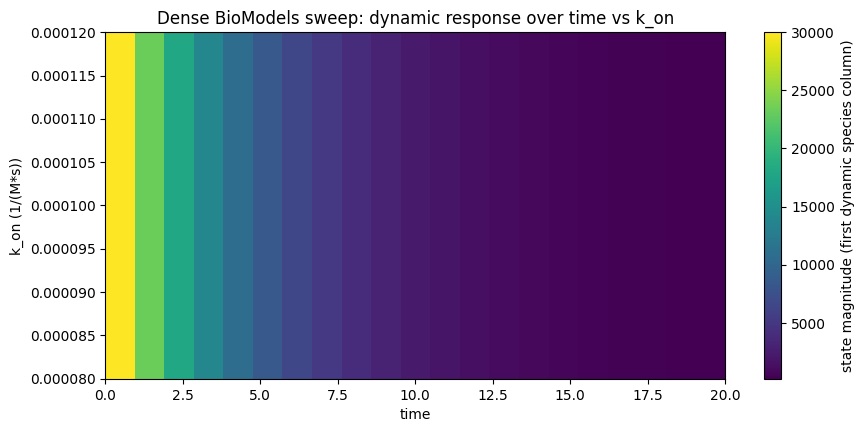

In [4]:
import csv
import json

import matplotlib.pyplot as plt
import numpy as np

registry_path = root / "tmp" / "run_registry.json"


def collect_dense_biomodel_sweeps() -> list[tuple[str, str, dict]]:
    if not registry_path.exists():
        return []
    registry = json.loads(registry_path.read_text())
    matches: list[tuple[str, str, dict]] = []
    for run_id, record_path in registry.items():
        candidate = Path(record_path)
        if not candidate.is_absolute():
            candidate = root / candidate
        if not candidate.exists():
            continue
        record = json.loads(candidate.read_text())
        sweep_rows_path = record.get("sweep_rows_path", "")
        if sweep_rows_path.startswith("tmp/tutorials/biomodels_store_dense/sweeps/"):
            matches.append((record.get("finished_at", ""), run_id, record))
    return matches


def parse_timeseries_from_row(row: dict[str, str]) -> tuple[np.ndarray, np.ndarray] | None:
    rows_blob = row.get("time_series__rows__json", "")
    if not rows_blob:
        return None

    col_items = []
    for key, value in row.items():
        if key.startswith("time_series__columns__"):
            try:
                idx = int(key.rsplit("__", 1)[1])
            except ValueError:
                continue
            col_items.append((idx, value))
    if not col_items:
        return None

    col_names = [name for _, name in sorted(col_items, key=lambda item: item[0])]
    table = json.loads(rows_blob)
    if not isinstance(table, list) or not table:
        return None

    matrix = np.array(
        [[float(entry.get(col, np.nan)) for col in col_names] for entry in table], dtype=float
    )
    if matrix.ndim != 2 or matrix.shape[1] == 0:
        return None

    first_col_is_time = col_names[0].lower() == "time" and np.all(np.diff(matrix[:, 0]) >= 0)
    if first_col_is_time:
        return matrix[:, 0], matrix[:, 1] if matrix.shape[1] > 1 else matrix[:, 0]
    return np.arange(matrix.shape[0], dtype=float), matrix[:, 0]


candidates = sorted(collect_dense_biomodel_sweeps(), reverse=True)
selected = None
series_by_k_on: list[tuple[float, np.ndarray, np.ndarray]] = []

for _, run_id, run_record in candidates:
    sweep_rows_path = root / run_record["sweep_rows_path"]
    rows = list(csv.DictReader(sweep_rows_path.read_text().splitlines()))
    rows = [row for row in rows if row.get("status") == "success"]

    trial_series: list[tuple[float, np.ndarray, np.ndarray]] = []
    for row in rows:
        parsed = parse_timeseries_from_row(row)
        if parsed is None:
            continue
        time, signal = parsed
        trial_series.append((float(row["k_on"]), time, signal))

    if trial_series:
        selected = (run_id, sweep_rows_path)
        series_by_k_on = trial_series
        break

if selected is None:
    print("No successful dense BioModels sweep with plottable time-series found yet.")
    print("Run Step 2 after dependencies/network (or local SBML cache) are available.")
else:
    run_id, sweep_rows_path = selected
    print("Using run id:", run_id)
    print("Sweep rows:", sweep_rows_path)

    series_by_k_on.sort(key=lambda item: item[0])
    min_len = min(len(item[2]) for item in series_by_k_on)
    k_vals = np.array([item[0] for item in series_by_k_on], dtype=float)
    time = series_by_k_on[0][1][:min_len]
    heat = np.vstack([item[2][:min_len] for item in series_by_k_on])

    plt.figure(figsize=(10, 4.5))
    im = plt.imshow(
        heat,
        origin="lower",
        aspect="auto",
        extent=[float(time[0]), float(time[-1]), float(k_vals[0]), float(k_vals[-1])],
        cmap="viridis",
    )
    plt.colorbar(im, label="state magnitude (first dynamic species column)")
    plt.title("Dense BioModels sweep: dynamic response over time vs k_on")
    plt.xlabel("time")
    plt.ylabel("k_on (1/(M*s))")
    plt.show()


## Scientific checkpoint

`k_on` is an association-rate constant: larger values typically mean faster complex formation. In the dynamic response above:

- Does increasing `k_on` shift high-activity regions earlier in time? Where exactly is the inflection?
- Are the regimes monotonic across the swept range, or do you see qualitatively different behavior at the high end?
- If you doubled the upper bound of the sweep, what would you expect to see? (The toy reflex is "more of the same"; biology often rewards a more cautious answer.)

**Common confusion (heads-up for T5/T6).** The heatmap above shows the *first species column* of the time-series. Real model output here has multiple species, and a real analysis would compute one or more **summary statistics per row** (peak time, area-under-curve, steady-state value) rather than picking a column. That per-row summarization is exactly the work surrogates are about to take over from you in T5 and T6 — instead of running 11 simulations and squinting at heatmaps, you fit a surrogate once and ask it for the summary at any `k_on` you want.


## Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| `PREFLIGHT: BioModels SBML simulator missing` | `libroadrunner`/`tellurium` absent from this kernel | `pip install libroadrunner tellurium` — **PyPI-only**, not on conda-forge. Then restart the kernel. |
| Step 2 skipped, but you installed roadrunner | Installed into a *different* env than the kernel | Compare the preflight's `Kernel env path` against where pip installed. They must match. |
| Hangs or fails fetching the SBML | No network, or BioModels is slow | Set `MM_BIOMODELS_OFFLINE=1` to use the cached copy and fail loudly instead of hanging. |
| `0 successful runs` / every DOE point failed | The worker subprocess ran in a different interpreter than the kernel | This was a real bug (fixed in `28835b8`). If it recurs, check `sweep_logs.jsonl` — per-point errors are recorded there, not in the summary line. |
| Sweep "succeeds" but outputs are all identical | The parameter isn't reaching the model | Inspect one row of `sweep_rows.csv` and confirm the input column actually varies. |

**The habit worth taking from this table:** the summary line is not the source of
truth. `sweep_logs.jsonl` holds the per-point errors, and a sweep can report a
tidy summary while every point underneath it failed — that exact false-success is
what prompted this tutorial's rewrite.

## Final check: T2's BioModels sweep produced data (or skipped cleanly)

Two-tier assertion — depends on whether libroadrunner was installed (preflight from Step 1):
- if `RUN_WILL_EXECUTE`: sweep_rows.csv exists with all DOE points status='success' AND `time_series__rows__json` has non-empty arrays (the SBML simulation actually ran);
- else: the preflight banner was printed and Step 2 was deliberately skipped.

In [5]:
# Self-check: T2's BioModels sweep produced data (or skipped per preflight).
import csv as _csv
import json as _json
if not RUN_WILL_EXECUTE:
    print(f"\n[T2 self-check OK] Step 2 skipped per preflight (LIBROADRUNNER_AVAILABLE={LIBROADRUNNER_AVAILABLE}, "
          f"OFFLINE={OFFLINE}, CACHE_READY={CACHE_READY}).")
else:
    _sweeps = sorted(
        (root / "tmp/tutorials/biomodels_store_dense/sweeps").glob("*/sweep_rows.csv"),
        key=lambda p: p.stat().st_mtime,
    )
    assert _sweeps, "No BioModels sweep_rows.csv produced — Step 2 didn't run an end-to-end sweep."
    _latest = _sweeps[-1]
    with open(_latest) as _f:
        _rows = list(_csv.DictReader(_f))
    _success = [r for r in _rows if r.get("status") == "success"]
    assert _success, (
        f"All {len(_rows)}/{len(_rows)} DOE points failed in {_latest}. "
        "Common cause: worker subprocess uses wrong Python env. Check sweep_logs.jsonl "
        "for the actual error."
    )
    # Spot-check that the time-series column actually has data, not just success-with-empty.
    _ts_col = next((c for c in _rows[0].keys() if c.endswith("__rows__json")), None)
    assert _ts_col, f"No time_series__rows__json column in {_latest} — output mapping mismatch."
    _ts_data = _json.loads(_success[0][_ts_col])
    assert len(_ts_data) > 1, f"time-series has only {len(_ts_data)} points in {_latest} — likely libroadrunner runtime error."
    print(f"\n[T2 self-check OK] {len(_success)}/{len(_rows)} success rows; time-series has {len(_ts_data)} points.")



[T2 self-check OK] 11/11 success rows; time-series has 21 points.
